## 1. What this notebook computes

A square matrix $M$ usually turns a vector into a vector that points somewhere
else. A few special directions are only stretched: $M v = \lambda v$. The
number $\lambda$ is an **eigenvalue** and $v$ an **eigenvector**. Eigenvalues
are everywhere in the course: the signature (4,4) of the author's spacetime is a
count of positive and negative eigenvalues of its metric, the gamma matrices
are known by their eigenvalues, and energies of quantum states are
eigenvalues. This notebook

- finds the eigenvalues and eigenvectors of a $2 \times 2$ matrix by hand and
  draws how the matrix turns the unit circle into an ellipse;
- derives the *characteristic polynomial* $\det(M - \lambda I)$ and the rules
  "the eigenvalues add up to the trace and multiply to the determinant";
- solves exactly the *chain matrix* (2 on the diagonal, $-1$ next to it), whose
  eigenvectors are sampled sine waves;
- shows that real rotation matrices have complex eigenvalues $e^{\pm i\alpha}$,
  while boosts have real ones $e^{\pm\varphi}$;
- proves that symmetric (and Hermitian) matrices have real eigenvalues and
  perpendicular eigenvectors, and checks it on random matrices;
- counts the positive and negative eigenvalues of the frame metric $\eta$ and of
  the author's metric $g$ (the signature (4,4)) and checks that no change of
  coordinates changes these counts (Sylvester's law of inertia);
- derives the eigenvalues of the eight real gamma matrices of the Revision
  record ($\pm 1$ or $\pm i$, eight times each) and of the matrix
  $\gamma(v) = v_a \gamma^a$ of a vector, which are $\pm\sqrt{Q(v)}$;
- finds the eigenvalues of the Hermitian matrix $B$ of the record, $+1$ and
  $-1$ eight times each: the signature (8,8);
- shows how a computer finds an eigenvalue by *power iteration*.

Every check prints a line that starts with PASS; where a check repeats a result
of the Revision record, a second line names the record file and its check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 01g (Eigenvalues, eigenvectors and the signature (4,4)) is the file
`Revision/textbook/notebooks/01g_eigenvalues_signature.ipynb` of the repository
Dirac_claude. It finds eigenvalues and eigenvectors by hand and with sympy and numpy,
derives the characteristic polynomial and the rules that the eigenvalues add up to the
trace and multiply to the determinant, solves the chain matrix of a grid exactly
(sine-shaped eigenvectors), shows that real rotations have complex eigenvalues and boosts
real ones, proves that symmetric and Hermitian matrices have real eigenvalues, counts the
positive and negative eigenvalues of the frame metric and of the author's metric (the
signature (4,4)) and checks that a change of coordinates never changes these counts
(Sylvester's law of inertia), derives the eigenvalues of the eight real gamma matrices of
the Revision record and of the Hermitian matrix B with its signature (8,8), and shows how
a computer finds an eigenvalue by power iteration. It needs a computer with Windows 11,
macOS or Linux, an internet connection for the installation, the program Git, and Python
3.12 or newer (the notebooks were built with Python 3.14.5) with these packages at
exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 01g_eigenvalues_signature.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 01g_eigenvalues_signature.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
01g_eigenvalues_signature.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/01g.captions.json`
- `Revision/textbook/figures/01g_1_circle_to_ellipse.png`
- `Revision/textbook/figures/01g_2_characteristic_polynomial.png`
- `Revision/textbook/figures/01g_3_chain_matrix.png`
- `Revision/textbook/figures/01g_4_rotation_and_boost.png`
- `Revision/textbook/figures/01g_5_random_spectra.png`
- `Revision/textbook/figures/01g_6_signature.png`
- `Revision/textbook/figures/01g_7_gamma_eigenvalues.png`
- `Revision/textbook/figures/01g_8_hermitian_b.png`
- `Revision/textbook/figures/01g_9_power_iteration.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 9 figure files of this notebook exist
    ALL 30 CHECKS PASSED (notebook 01g)

and the notebook must show 9 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/01g_eigenvalues_signature.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for a file below Revision/gkd_lovelock, Revision/algebra or
  Revision/theory: the notebook reads Revision records of the repository; your copy of
  the repository is incomplete. Download it again with git clone and open the notebook
  inside the new copy.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 01g (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 01g (Eigenvalues, eigenvectors and the signature (4,4)) is the file
# Revision/textbook/notebooks/01g_eigenvalues_signature.ipynb of the repository
# Dirac_claude. It finds eigenvalues and eigenvectors by hand and with sympy and numpy,
# derives the characteristic polynomial and the rules that the eigenvalues add up to the
# trace and multiply to the determinant, solves the chain matrix of a grid exactly
# (sine-shaped eigenvectors), shows that real rotations have complex eigenvalues and
# boosts real ones, proves that symmetric and Hermitian matrices have real eigenvalues,
# counts the positive and negative eigenvalues of the frame metric and of the author's
# metric (the signature (4,4)) and checks that a change of coordinates never changes
# these counts (Sylvester's law of inertia), derives the eigenvalues of the eight real
# gamma matrices of the Revision record and of the Hermitian matrix B with its signature
# (8,8), and shows how a computer finds an eigenvalue by power iteration. It needs a
# computer with Windows 11, macOS or Linux, an internet connection for the installation,
# the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the
# other packages run Jupyter, the program that shows and runs notebooks. It does not need
# Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 01g_eigenvalues_signature.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 01g_eigenvalues_signature.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 01g_eigenvalues_signature.ipynb (in the same folder, without running the cells again)
# to read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/01g.captions.json
# - Revision/textbook/figures/01g_1_circle_to_ellipse.png
# - Revision/textbook/figures/01g_2_characteristic_polynomial.png
# - Revision/textbook/figures/01g_3_chain_matrix.png
# - Revision/textbook/figures/01g_4_rotation_and_boost.png
# - Revision/textbook/figures/01g_5_random_spectra.png
# - Revision/textbook/figures/01g_6_signature.png
# - Revision/textbook/figures/01g_7_gamma_eigenvalues.png
# - Revision/textbook/figures/01g_8_hermitian_b.png
# - Revision/textbook/figures/01g_9_power_iteration.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 9 figure files of this notebook exist
#     ALL 30 CHECKS PASSED (notebook 01g)
#
# and the notebook must show 9 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/01g_eigenvalues_signature.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for a file below Revision/gkd_lovelock, Revision/algebra or
#   Revision/theory: the notebook reads Revision records of the repository; your copy of
#   the repository is incomplete. Download it again with git clone and open the notebook
#   inside the new copy.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "01g"  # this notebook: chapter 01, example g


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 01g complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Eigenvalue, eigenvector**: a number $\lambda$ and a vector $v \neq 0$ with
  $M v = \lambda v$ for a square matrix $M$. Any multiple $c v$ ($c \neq 0$) is
  an eigenvector too, so only the *direction* of $v$ matters.
- **Spectrum**: the list of all eigenvalues of a matrix.
- **Characteristic polynomial**: $p(\lambda) = \det(M - \lambda I)$, a
  polynomial in $\lambda$ whose roots are the eigenvalues.
- **Root** (or zero) of a polynomial: a number where it is 0. A root that
  appears $k$ times in the factorised polynomial has **multiplicity** $k$.
- **Trace** $\mathrm{tr}\,M$: the sum of the diagonal entries.
- **Determinant** $\det M$: the number of notebook 01a; $\det M \neq 0$ exactly
  when $M$ can be undone (inverted).
- **Length** (norm) of a vector, $|v| = \sqrt{v_1^2 + \dots + v_n^2}$; a **unit
  vector** has length 1.
- **Perpendicular** (orthogonal) vectors: $u^T w = \sum_i u_i w_i = 0$.
- **Symmetric matrix**: $S^T = S$. **Orthogonal matrix**: $O^T O = I$; its
  columns are perpendicular unit vectors.
- **Complex conjugate** $z^*$ and **conjugate transpose**
  $M^\dagger = (M^*)^T$ (conjugate every entry, then exchange rows and
  columns); for a column $v$, $v^\dagger v = \sum_i |v_i|^2$.
- **Hermitian matrix**: $H^\dagger = H$; a real Hermitian matrix is a
  symmetric matrix.
- **Quadratic form** of a symmetric matrix $S$: the number
  $Q(v) = v^T S v = S_{ab} v^a v^b$.
- **Signature** $(p, q)$ of a symmetric matrix: $p$ eigenvalues are positive
  and $q$ negative (the rest are 0).
- **Sylvester's law of inertia**: the matrices $S$ and $P^T S P$ ($P$
  invertible) have the same signature.
- **Light-like** vector: $v \neq 0$ with $Q(v) = 0$ (notebook 01e).
- **Nilpotent matrix**: a matrix $N \neq 0$ with $N^k = 0$ for some power $k$;
  all its eigenvalues are 0.
- **Power iteration**: multiply a vector by $M$ again and again and rescale it
  to length 1; it turns towards the eigenvector of the eigenvalue of largest
  size.

## 4. The physical and mathematical situation

**Why a determinant decides.** $M v = \lambda v$ can be written
$(M - \lambda I) v = 0$ (move $\lambda v = \lambda I v$ to the left side). If
$\det(M - \lambda I) \neq 0$, the matrix $M - \lambda I$ can be undone, and
undoing it on both sides gives $v = 0$: no eigenvector. So eigenvalues are
exactly the numbers with

$$p(\lambda) = \det(M - \lambda I) = 0.$$

By the Leibniz formula every term of $\det(M - \lambda I)$ is a product of $n$
entries, and at most $n$ of them contain $\lambda$; so $p$ is a polynomial of
degree $n$. A theorem of algebra (the *fundamental theorem of algebra*) says
that such a polynomial has exactly $n$ roots $\lambda_1, \dots, \lambda_n$ when
complex numbers are allowed and a repeated root is counted as often as its
multiplicity says; so an $n \times n$ matrix has $n$ eigenvalues, some of which
may be complex or repeated.

**Trace and determinant.** A polynomial of degree $n$ whose highest term is
$(-\lambda)^n$ and whose roots are $\lambda_1, \dots, \lambda_n$ is

$$p(\lambda) = (\lambda_1 - \lambda)(\lambda_2 - \lambda)\cdots(\lambda_n -
\lambda).$$

Setting $\lambda = 0$ gives $p(0) = \det M = \lambda_1 \lambda_2 \cdots
\lambda_n$: the determinant is the **product** of the eigenvalues. Multiplying
out, the terms with $\lambda^{n-1}$ are
$(-1)^{n-1}(\lambda_1 + \dots + \lambda_n)\lambda^{n-1}$. In the Leibniz
formula only the product of the diagonal entries,
$(M_{11} - \lambda)\cdots(M_{nn} - \lambda)$, contains $\lambda^{n-1}$ (every
other term misses at least two diagonal entries), and its $\lambda^{n-1}$ terms
are $(-1)^{n-1}(M_{11} + \dots + M_{nn})\lambda^{n-1}$. Comparing: the
**sum** of the eigenvalues is the trace.

**The course.** The author's spacetime has the frame metric
$\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$ in the order
$x_1, \dots, x_8$ ($x_1, x_2, x_3$ space, $x_4$ time, $x_5, x_6, x_7$ the
three extra times, $x_8$ the hidden direction) and the metric

$$g = \mathrm{diag}\big(e^{2a_4} s, e^{2a_4} s, e^{2a_4} s, -1,
-e^{-2a_4} s, -e^{-2a_4} s, -e^{-2a_4} s, \cot^2 z\big),\quad
s = \sin^{1/3} z,\ z = 6 H x_8,$$

whose extra-time entries shrink like $e^{-2a_4}$ as $a_4$ grows: the extra
times deflate exponentially. "Signature (4,4)" means: four positive and four
negative eigenvalues. The eight real $16 \times 16$ gamma matrices obey
$(\gamma^a)^2 = \eta^{aa} I$, which fixes their eigenvalues; and the matrix
$B = -i C \gamma^{(x_4)}$ of the record, which gives the charge density of
the fields of the theory, is Hermitian with eigenvalues $+1$ and $-1$.

## 5. A 2 x 2 example by hand

Take $M$ with the rows $(2, 1)$ and $(1, 2)$. Line by line:

$$\det(M - \lambda I) = (2 - \lambda)(2 - \lambda) - 1 \cdot 1$$

(the $2 \times 2$ determinant $ad - bc$ of the matrix with rows
$(2 - \lambda, 1)$ and $(1, 2 - \lambda)$),

$$= \lambda^2 - 4\lambda + 4 - 1 = \lambda^2 - 4\lambda + 3$$

(multiply out), $= (\lambda - 1)(\lambda - 3)$ (two numbers with product 3 and
sum 4). So the eigenvalues are 1 and 3. For $\lambda = 3$ the equation
$(M - 3I)v = 0$ reads $-v_1 + v_2 = 0$ (both rows say the same), so
$v = (1, 1)$; for $\lambda = 1$ it reads $v_1 + v_2 = 0$, so $v = (1, -1)$.
Check: $3 + 1 = 4 = \mathrm{tr}\,M$ and $3 \cdot 1 = 3 = 4 - 1 = \det M$.

The next cell repeats this with sympy (`factor` writes a polynomial as a
product, `solve` finds its roots), checks $M v = \lambda v$ for both
eigenvectors, and compares with numpy's `eigh` (the eigenvalue program for
symmetric matrices; it returns the eigenvalues from the smallest up and the
eigenvectors, of length 1, as the columns of a matrix).

In [2]:
import math  # square roots and pi

import numpy as np  # arrays and numerical linear algebra
import sympy as sp  # exact algebra

lam = sp.Symbol("lambda")  # the unknown eigenvalue
M = sp.Matrix([[2, 1], [1, 2]])
char_poly = sp.expand((M - lam * sp.eye(2)).det())  # det(M - lambda I)
say(f"det(M - lambda I) = {char_poly} = {sp.factor(char_poly)}")
eigenvalues = sorted(sp.solve(char_poly, lam))  # the roots
check(eigenvalues == [1, 3], "the eigenvalues of M are 1 and 3")
v3, v1 = sp.Matrix([1, 1]), sp.Matrix([1, -1])
check(M * v3 == 3 * v3 and M * v1 == 1 * v1,
      "M (1, 1) = 3 (1, 1) and M (1, -1) = 1 (1, -1)")
check(sum(eigenvalues) == M.trace() == 4 and eigenvalues[0] * eigenvalues[1]
      == M.det() == 3, "sum of the eigenvalues = trace = 4, product = det = 3")
values, vectors = np.linalg.eigh(np.array(M.tolist(), dtype=float))
# The sign of an eigenvector is free (v and -v are both eigenvectors), and
# different computers may return either; make the first entry of each column
# positive so that every computer prints the same.
vectors = vectors * np.sign(vectors[0])
say(f"numpy eigh: eigenvalues {values.round(12).tolist()}")
say(f"            eigenvectors (columns) {vectors.round(6).tolist()}")
check(np.allclose(values, [1.0, 3.0], atol=1e-12) and
      abs(abs(vectors[:, 1] @ np.array([1.0, 1.0])) - math.sqrt(2)) < 1e-12,
      "numpy finds the eigenvalues 1, 3 and the direction (1, 1) for 3")

det(M - lambda I) = lambda**2 - 4*lambda + 3 = (lambda - 3)*(lambda - 1)
PASS the eigenvalues of M are 1 and 3
PASS M (1, 1) = 3 (1, 1) and M (1, -1) = 1 (1, -1)
PASS sum of the eigenvalues = trace = 4, product = det = 3
numpy eigh: eigenvalues [1.0, 3.0]
            eigenvectors (columns) [[0.707107, 0.707107], [-0.707107, 0.707107]]
PASS numpy finds the eigenvalues 1, 3 and the direction (1, 1) for 3


The next cell shows the meaning of the result. It takes 721 points on the unit
circle (all vectors of length 1), multiplies each by $M$ and draws the image,
an ellipse. The two eigenvector directions $(1, 1)/\sqrt 2$ and
$(1, -1)/\sqrt 2$ are drawn with their images: they keep their direction and
are stretched by 3 and by 1. The vector $u = (1, 0)$ is drawn as well: its
image $M u = (2, 1)$ points in another direction. The cell checks that the
longest and the shortest image have the lengths 3 and 1, the two eigenvalues
(for a symmetric matrix the ellipse's half-axes are the eigenvalues' sizes).

longest image 3.000000, shortest image 1.000000
PASS the unit circle becomes an ellipse with half-axes 3 and 1


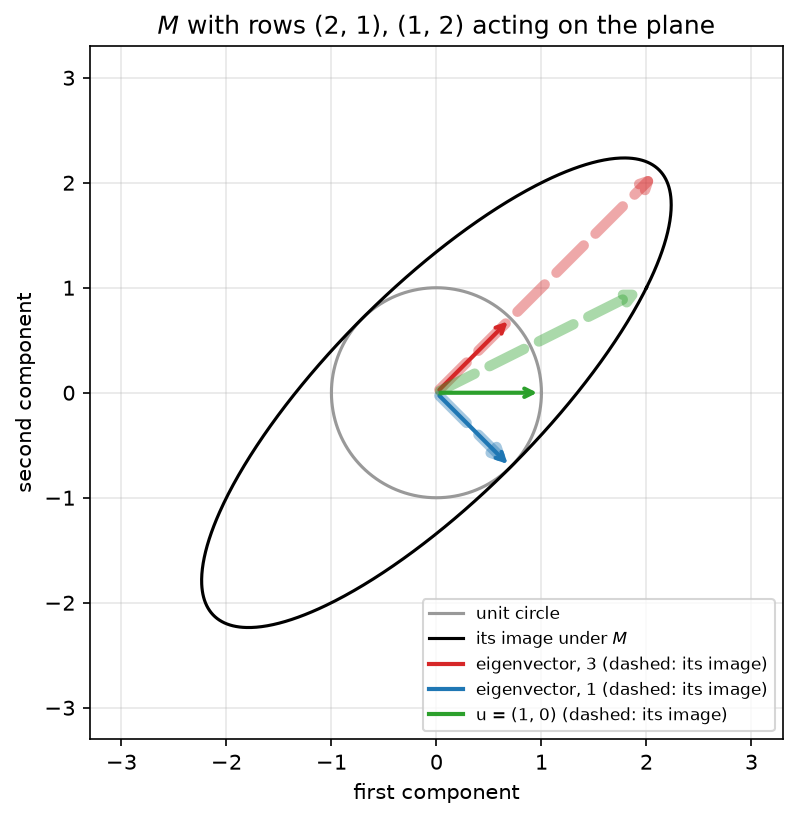

Figure 01g.1 saved as Revision/textbook/figures/01g_1_circle_to_ellipse.png


In [3]:
angles = np.linspace(0.0, 2.0 * np.pi, 721)  # every half degree
circle = np.array([np.cos(angles), np.sin(angles)])  # 2 rows: x and y
M_numbers = np.array(M.tolist(), dtype=float)
ellipse = M_numbers @ circle  # every point of the circle multiplied by M
lengths = np.sqrt((ellipse ** 2).sum(axis=0))  # length of every image
say(f"longest image {lengths.max():.6f}, shortest image {lengths.min():.6f}")
check(abs(lengths.max() - 3) < 1e-9 and abs(lengths.min() - 1) < 1e-4,
      "the unit circle becomes an ellipse with half-axes 3 and 1")
fig, ax = plt.subplots(figsize=(6.6, 6.0))
ax.plot(circle[0], circle[1], color="0.6", label="unit circle")
ax.plot(ellipse[0], ellipse[1], color="black", label="its image under $M$")
arrows = [(np.array([1.0, 1.0]) / math.sqrt(2), "tab:red", "eigenvector, 3"),
          (np.array([1.0, -1.0]) / math.sqrt(2), "tab:blue", "eigenvector, 1"),
          (np.array([1.0, 0.0]), "tab:green", "u = (1, 0)")]
for vector, color, name in arrows:
    image = M_numbers @ vector
    # the image first: thick, dashed and see-through, so that the vector drawn
    # on top of it stays visible where the two coincide
    ax.annotate("", xy=image, xytext=(0, 0),
                arrowprops={"arrowstyle": "->", "color": color, "lw": 5,
                            "linestyle": "--", "alpha": 0.4})
    ax.annotate("", xy=vector, xytext=(0, 0),
                arrowprops={"arrowstyle": "->", "color": color, "lw": 2})
    ax.plot([], [], color=color, lw=2, label=f"{name} (dashed: its image)")
ax.set_aspect("equal")
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_xlabel("first component")
ax.set_ylabel("second component")
ax.set_title("$M$ with rows (2, 1), (1, 2) acting on the plane")
ax.legend(loc="lower right", fontsize=8)
save_figure(fig, "circle_to_ellipse",
            "The unit circle (grey) and its image under the matrix $M$ with rows "
            "(2, 1) and (1, 2), an ellipse (black); axes the two components of a "
            "vector (pure numbers). Thin solid arrows are vectors of length 1, "
            "thick dashed see-through arrows their images. The eigenvector "
            "$(1, 1)/\\sqrt{2}$ (red) keeps its direction and is stretched by 3, "
            "the eigenvector $(1, -1)/\\sqrt{2}$ (blue) keeps its direction and "
            "its length (eigenvalue 1, so its image lies under it), while "
            "$u = (1, 0)$ (green) is turned to $(2, 1)$. "
            "The half-axes of the ellipse lie along the eigenvectors.")

## 6. The characteristic polynomial and the chain matrix

The next cell takes the $3 \times 3$ *chain matrix* $T_3$ with 2 on the
diagonal and $-1$ just above and just below it. Its characteristic polynomial,
multiplied out by sympy, is $-\lambda^3 + 6\lambda^2 - 10\lambda + 4 =
-(\lambda - 2)(\lambda^2 - 4\lambda + 2)$, with the roots $2$ and
$2 \pm \sqrt 2$ (the quadratic formula: $\lambda = 2 \pm \sqrt{4 - 2}$). The
cell checks the roots, the sum rule ($6 = \mathrm{tr}\,T_3$) and the product
rule ($(2 - \sqrt 2) \cdot 2 \cdot (2 + \sqrt 2) = 2 \cdot (4 - 2) = 4 =
\det T_3$), and draws $p(\lambda)$ with its three roots.

det(T3 - lambda I) = -lambda**3 + 6*lambda**2 - 10*lambda + 4 = -(lambda - 2)*(lambda**2
    - 4*lambda + 2)
roots: [2 - sqrt(2), 2, sqrt(2) + 2]
PASS the eigenvalues of T3 are 2 - sqrt 2, 2 and 2 + sqrt 2
PASS sum of the eigenvalues = trace = 6, product = det = 4


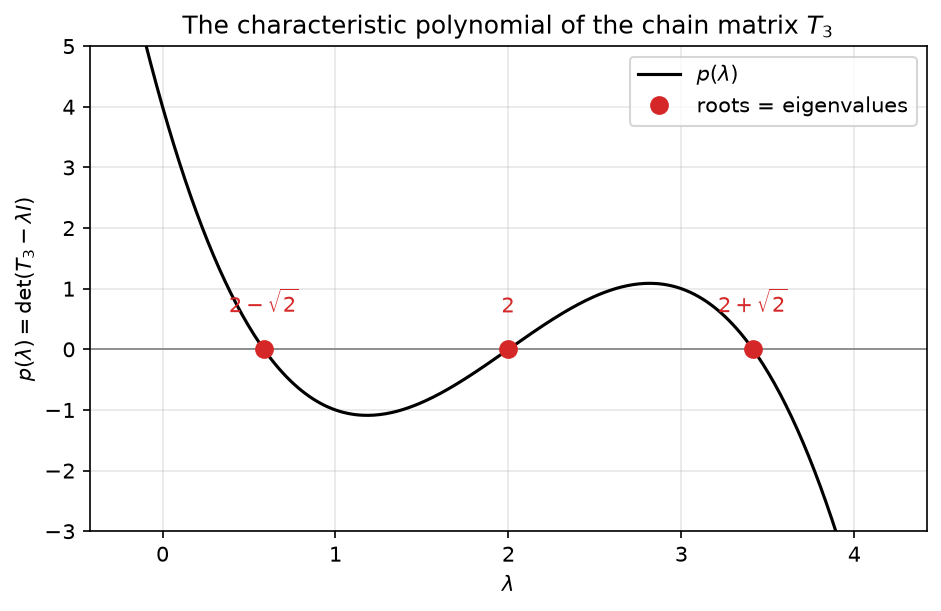

Figure 01g.2 saved as Revision/textbook/figures/01g_2_characteristic_polynomial.png


In [4]:
T3 = sp.Matrix([[2, -1, 0], [-1, 2, -1], [0, -1, 2]])
p3 = sp.expand((T3 - lam * sp.eye(3)).det())
say(f"det(T3 - lambda I) = {p3} = {sp.factor(p3)}")
roots3 = sorted(sp.roots(p3, lam).keys(), key=lambda r: float(r))  # small first
say(f"roots: {roots3}")
check(roots3 == [2 - sp.sqrt(2), 2, 2 + sp.sqrt(2)],
      "the eigenvalues of T3 are 2 - sqrt 2, 2 and 2 + sqrt 2")
check(sp.simplify(sum(roots3) - T3.trace()) == 0 and
      sp.simplify(roots3[0] * roots3[1] * roots3[2] - T3.det()) == 0,
      "sum of the eigenvalues = trace = 6, product = det = 4")
p3_numbers = sp.lambdify(lam, p3, "numpy")  # the polynomial as a numpy function
grid = np.linspace(-0.2, 4.2, 400)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(grid, p3_numbers(grid), color="black", label="$p(\\lambda)$")
ax.axhline(0.0, color="0.5", lw=0.8)
root_values = [float(r) for r in roots3]
ax.plot(root_values, [0.0, 0.0, 0.0], "o", color="tab:red", ms=8,
        label="roots = eigenvalues")
for r_text, r_value in zip(["$2 - \\sqrt{2}$", "$2$", "$2 + \\sqrt{2}$"],
                           root_values):
    ax.text(r_value, 0.6, r_text, ha="center", color="tab:red")
ax.set_xlabel("$\\lambda$")
ax.set_ylabel("$p(\\lambda) = \\det(T_3 - \\lambda I)$")
ax.set_title("The characteristic polynomial of the chain matrix $T_3$")
ax.set_ylim(-3.0, 5.0)
ax.legend(loc="upper right");
save_figure(fig, "characteristic_polynomial",
            "The characteristic polynomial $p(\\lambda) = \\det(T_3 - \\lambda I) "
            "= -\\lambda^3 + 6\\lambda^2 - 10\\lambda + 4$ of the $3 \\times 3$ "
            "chain matrix $T_3$ (2 on the diagonal, $-1$ next to it) against "
            "$\\lambda$ (black), with its three roots $2 - \\sqrt{2}$, 2 and "
            "$2 + \\sqrt{2}$ (red dots); both axes pure numbers. The curve crosses "
            "zero exactly at the eigenvalues; their sum is the trace 6 and their "
            "product the determinant $p(0) = 4$.")

The chain matrix $T_n$ of any size $n$ has an exact solution. Row $j$ of
$T_n v$ is $-v_{j-1} + 2v_j - v_{j+1}$, with $v_0 = v_{n+1} = 0$ (the rows at
the ends have only one neighbour). Try $v_j = \sin(j\theta)$:

$$\sin((j-1)\theta) + \sin((j+1)\theta) = 2\sin(j\theta)\cos\theta$$

(the addition theorems $\sin(x \pm y) = \sin x\cos y \pm \cos x\sin y$ with
$x = j\theta$, $y = \theta$, added: the $\cos x \sin y$ terms cancel), so

$$-v_{j-1} + 2v_j - v_{j+1} = (2 - 2\cos\theta)\sin(j\theta).$$

The start $v_0 = \sin 0 = 0$ holds for every $\theta$; the end
$v_{n+1} = \sin((n+1)\theta) = 0$ holds for $\theta = k\pi/(n+1)$,
$k = 1, \dots, n$. So the eigenvalues are $\lambda_k = 2 - 2\cos(k\pi/(n+1))$
and the eigenvectors are sine waves sampled at the points $j = 1, \dots, n$.
This matrix comes back whenever a second derivative is computed on a grid of
points; then the sine waves are the shapes of a vibrating string or of a
quantum particle in a box. The next cell checks the formula for $n = 10$ with
numpy and draws the first three eigenvectors and all ten eigenvalues.

largest difference eigh - formula: 8.9e-16
PASS T_10 has the eigenvalues 2 - 2 cos(k pi/11), k = 1 ... 10
PASS every eigenvector of T_10 is a sampled sine wave sin(j k pi/11)


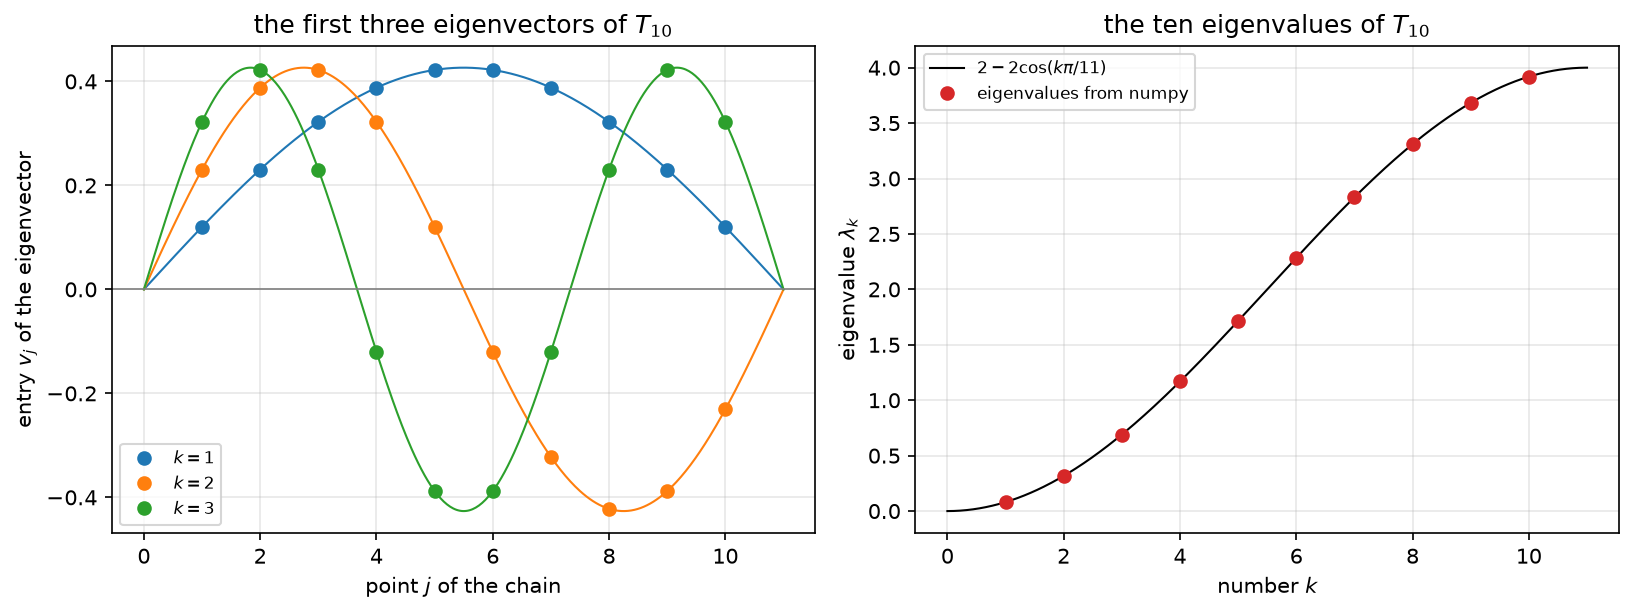

Figure 01g.3 saved as Revision/textbook/figures/01g_3_chain_matrix.png


In [5]:
n = 10
T = 2 * np.eye(n) - np.eye(n, k=1) - np.eye(n, k=-1)  # k=1: just above the diagonal
values_T, vectors_T = np.linalg.eigh(T)  # eigenvalues from the smallest up
k = np.arange(1, n + 1)
formula = 2 - 2 * np.cos(k * np.pi / (n + 1))
say(f"largest difference eigh - formula: {np.max(np.abs(values_T - formula)):.1e}")
check(np.allclose(values_T, formula, rtol=0, atol=1e-12),
      "T_10 has the eigenvalues 2 - 2 cos(k pi/11), k = 1 ... 10")
j = np.arange(1, n + 1)  # the points of the chain
sines = np.array([np.sin(j * kk * np.pi / (n + 1)) for kk in k]).T  # columns
sines = sines / np.sqrt((sines ** 2).sum(axis=0))  # length 1
overlaps = np.abs((vectors_T * sines).sum(axis=0))  # |cos of the angle|, column-wise
check(np.allclose(overlaps, 1.0, rtol=0, atol=1e-12),
      "every eigenvector of T_10 is a sampled sine wave sin(j k pi/11)")
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.2))
fine = np.linspace(0, n + 1, 400)  # the sine curves between the points
for kk, color in zip((1, 2, 3), ("tab:blue", "tab:orange", "tab:green")):
    column = vectors_T[:, kk - 1] * np.sign(vectors_T[0, kk - 1])  # first entry > 0
    scale = column[0] / math.sin(kk * math.pi / (n + 1))
    left.plot(fine, scale * np.sin(fine * kk * math.pi / (n + 1)), color=color, lw=1)
    left.plot(j, column, "o", color=color, label=f"$k = {kk}$")
left.axhline(0, color="0.5", lw=0.8)
left.set_xlabel("point $j$ of the chain")
left.set_ylabel("entry $v_j$ of the eigenvector")
left.set_title("the first three eigenvectors of $T_{10}$")
left.legend(fontsize=8)
fine_k = np.linspace(0, n + 1, 400)
right.plot(fine_k, 2 - 2 * np.cos(fine_k * np.pi / (n + 1)), color="black", lw=1,
           label="$2 - 2\\cos(k\\pi/11)$")
right.plot(k, values_T, "o", color="tab:red", label="eigenvalues from numpy")
right.set_xlabel("number $k$")
right.set_ylabel("eigenvalue $\\lambda_k$")
right.set_title("the ten eigenvalues of $T_{10}$")
right.legend(fontsize=8, loc="upper left")
fig.tight_layout()
save_figure(fig, "chain_matrix",
            "The $10 \\times 10$ chain matrix $T_{10}$ (2 on the diagonal, $-1$ "
            "next to it). Left: the entries $v_j$ of its eigenvectors for the "
            "three smallest eigenvalues $k = 1, 2, 3$ (dots) against the point "
            "$j = 1$ to 10, with the sine curves $\\sin(jk\\pi/11)$ through them "
            "(lines): half a wave, a full wave, one and a half waves. Right: the "
            "ten eigenvalues from numpy (red dots) on the curve "
            "$2 - 2\\cos(k\\pi/11)$ (black) against $k$; all axes pure numbers.")

## 7. Real matrices with complex eigenvalues: rotations and boosts

The rotation matrix $R(\alpha)$ with rows $(\cos\alpha, -\sin\alpha)$ and
$(\sin\alpha, \cos\alpha)$ turns every vector (notebook 01b), so for
$0 < \alpha < \pi$ no real direction is kept. Its characteristic polynomial is

$$(\cos\alpha - \lambda)^2 + \sin^2\alpha = \lambda^2 - 2\cos\alpha\,\lambda +
1$$

(multiply out and use $\cos^2\alpha + \sin^2\alpha = 1$), with the roots
$\lambda = \cos\alpha \pm \sqrt{\cos^2\alpha - 1} = \cos\alpha \pm
i\sin\alpha = e^{\pm i\alpha}$: complex numbers of modulus 1, with the complex
eigenvectors $(1, \mp i)$. For $\alpha = \pi/2$, $R$ is the matrix $J$ of
notebook 01b with $J^2 = -I$, and its eigenvalues are $\pm i$.

The boost $\Lambda(\varphi)$ with rows $(\cosh\varphi, \sinh\varphi)$ and
$(\sinh\varphi, \cosh\varphi)$ has the characteristic polynomial
$\lambda^2 - 2\cosh\varphi\,\lambda + 1$ (now
$\cosh^2\varphi - \sinh^2\varphi = 1$), with the real roots
$\cosh\varphi \pm \sinh\varphi = e^{\pm\varphi}$ and the eigenvectors
$(1, \pm 1)$, the two light-like directions.

A real matrix can have complex eigenvalues, but they come in pairs: taking the
complex conjugate of $M v = \lambda v$ for a real $M$ gives
$M v^* = \lambda^* v^*$, so $\lambda^*$ is an eigenvalue too. The next cell
checks all of this exactly with sympy (`expand_complex` writes a number as
real part plus $i$ times imaginary part) and draws the eigenvalues.

In [6]:
alpha, phi = sp.symbols("alpha phi", real=True)
R = sp.Matrix([[sp.cos(alpha), -sp.sin(alpha)], [sp.sin(alpha), sp.cos(alpha)]])
p_rot = sp.expand((R - lam * sp.eye(2)).det())
check(sp.simplify(p_rot - (lam ** 2 - 2 * sp.cos(alpha) * lam + 1)) == 0,
      "det(R - lambda I) = lambda^2 - 2 cos(alpha) lambda + 1")
rot_ok = True
for sign_value in (1, -1):  # the eigenvalue e^(+-i alpha), eigenvector (1, -+i)
    eigen = sp.exp(sign_value * sp.I * alpha)
    vector = sp.Matrix([1, -sign_value * sp.I])
    gap = (R * vector - eigen * vector).applyfunc(
        lambda e: sp.simplify(sp.expand_complex(e)))
    rot_ok &= gap == sp.zeros(2, 1)
check(rot_ok, "R(alpha) (1, -+i) = e^(+-i alpha) (1, -+i) for every angle alpha")
J = R.subs(alpha, sp.pi / 2)  # the matrix of i
say(f"J = {J.tolist()}, eigenvalues {sorted(J.eigenvals().keys(), key=str)}")
check(set(J.eigenvals().keys()) == {sp.I, -sp.I}, "the eigenvalues of J are +i, -i")
boost = sp.Matrix([[sp.cosh(phi), sp.sinh(phi)], [sp.sinh(phi), sp.cosh(phi)]])
boost_ok = True
for sign_value in (1, -1):  # the eigenvalue e^(+-phi), eigenvector (1, +-1)
    vector = sp.Matrix([1, sign_value])
    gap = (boost * vector - sp.exp(sign_value * phi) * vector).applyfunc(
        lambda e: sp.simplify(e.rewrite(sp.exp)))
    boost_ok &= gap == sp.zeros(2, 1)
check(boost_ok, "a boost has the real eigenvalues e^(+-phi) with the light-like "
      "eigenvectors (1, +-1)")
generator = np.random.default_rng(12345)  # random numbers with a fixed seed
pairs_ok = True
for _ in range(200):  # 200 random real 5 x 5 matrices
    found = np.linalg.eigvals(generator.normal(size=(5, 5)))
    pairs_ok &= np.allclose(np.sort_complex(found), np.sort_complex(found.conj()))
check(pairs_ok, "the complex eigenvalues of 200 random real 5 x 5 matrices come "
      "in conjugate pairs")

PASS det(R - lambda I) = lambda^2 - 2 cos(alpha) lambda + 1
PASS R(alpha) (1, -+i) = e^(+-i alpha) (1, -+i) for every angle alpha
J = [[0, -1], [1, 0]], eigenvalues [-I, I]
PASS the eigenvalues of J are +i, -i
PASS a boost has the real eigenvalues e^(+-phi) with the light-like eigenvectors (1, +-1)
PASS the complex eigenvalues of 200 random real 5 x 5 matrices come in conjugate pairs


The next cell draws the eigenvalue pairs $e^{\pm i\alpha}$ of rotations by
$30, 60, \dots, 180$ degrees on the unit circle of the complex plane (left) and
the eigenvalues $e^{\varphi}$ and $e^{-\varphi}$ of boosts against the rapidity
$\varphi$ (right), whose product is always 1.

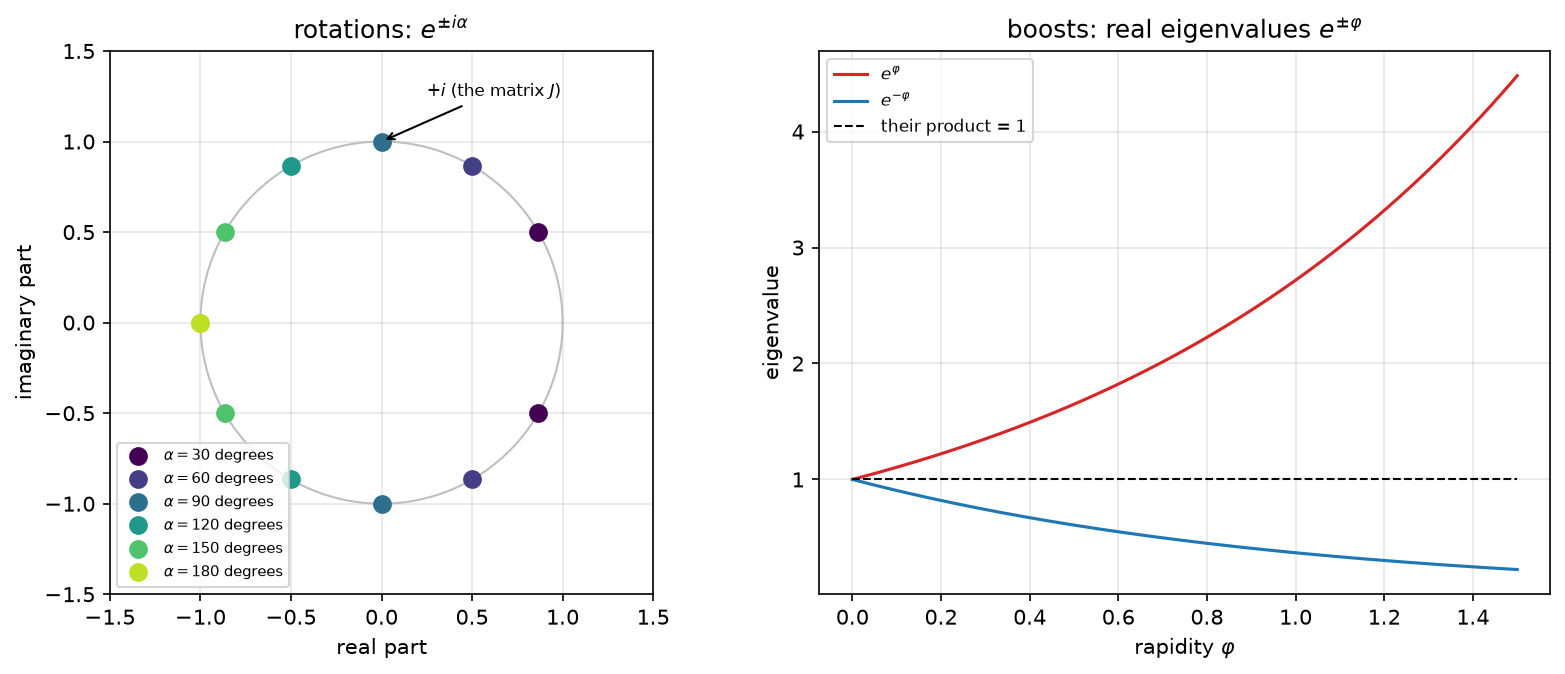

Figure 01g.4 saved as Revision/textbook/figures/01g_4_rotation_and_boost.png


In [7]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.6))
circle_line = np.exp(1j * np.linspace(0, 2 * np.pi, 400))
left.plot(circle_line.real, circle_line.imag, color="0.75", lw=1)
colors = plt.cm.viridis(np.linspace(0.0, 0.9, 6))  # six colours from a colour map
for step, color in zip(range(1, 7), colors):
    angle = step * np.pi / 6
    eig = np.linalg.eigvals(np.array([[np.cos(angle), -np.sin(angle)],
                                      [np.sin(angle), np.cos(angle)]]))
    left.plot(eig.real, eig.imag, "o", color=color, ms=8,
              label=f"$\\alpha = {30 * step}$ degrees")
left.annotate("$+i$ (the matrix $J$)", xy=(0, 1), xytext=(0.25, 1.25), fontsize=8,
              arrowprops={"arrowstyle": "->"})
left.set_aspect("equal")
left.set_xlim(-1.5, 1.5)
left.set_ylim(-1.5, 1.5)
left.set_xlabel("real part")
left.set_ylabel("imaginary part")
left.set_title("rotations: $e^{\\pm i\\alpha}$")
left.legend(fontsize=7, loc="lower left")
rapidity = np.linspace(0.0, 1.5, 200)
right.plot(rapidity, np.exp(rapidity), color="tab:red", label="$e^{\\varphi}$")
right.plot(rapidity, np.exp(-rapidity), color="tab:blue", label="$e^{-\\varphi}$")
right.plot(rapidity, np.exp(rapidity) * np.exp(-rapidity), "k--", lw=1,
           label="their product = 1")
right.set_xlabel("rapidity $\\varphi$")
right.set_ylabel("eigenvalue")
right.set_title("boosts: real eigenvalues $e^{\\pm\\varphi}$")
right.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "rotation_and_boost",
            "Left: the eigenvalues $e^{\\pm i\\alpha}$ of the real rotation "
            "matrices $R(\\alpha)$ for $\\alpha = 30$ to 180 degrees in steps of "
            "30 (one colour per angle) in the complex plane, on the unit circle "
            "(grey); horizontal axis the real part, vertical axis the imaginary "
            "part. Each pair is mirror-symmetric in the real axis; $\\alpha = 90$ "
            "degrees gives $\\pm i$, the eigenvalues of $J$. Right: the real "
            "eigenvalues $e^{\\varphi}$ (red) and $e^{-\\varphi}$ (blue) of a "
            "boost against its rapidity $\\varphi$ (pure numbers); their product "
            "is always 1 (dashed).")

## 8. Symmetric matrices: real eigenvalues, perpendicular eigenvectors

**Claim 1.** A real symmetric matrix $S$ has only real eigenvalues. **Proof**,
line by line. Let $S v = \lambda v$ with a column $v \neq 0$ that may be
complex.

- Conjugate and transpose both sides: $v^\dagger S^\dagger = \lambda^*
  v^\dagger$, and $S^\dagger = S$ because $S$ is real ($S^* = S$) and
  symmetric ($S^T = S$); so $v^\dagger S = \lambda^* v^\dagger$.
- Multiply $S v = \lambda v$ from the left by $v^\dagger$:
  $v^\dagger S v = \lambda\, v^\dagger v$.
- Multiply $v^\dagger S = \lambda^* v^\dagger$ from the right by $v$:
  $v^\dagger S v = \lambda^*\, v^\dagger v$.
- Subtract the two lines: $0 = (\lambda - \lambda^*)\, v^\dagger v$.
- $v^\dagger v = |v_1|^2 + \dots + |v_n|^2 > 0$, so $\lambda = \lambda^*$:
  $\lambda$ is real.

The same lines, with $S^\dagger = S$ as the only property used, prove it for a
complex **Hermitian** matrix.

**Claim 2.** Eigenvectors of a symmetric matrix with different eigenvalues are
perpendicular. **Proof.** Let $S u = \lambda u$, $S w = \mu w$, $\lambda \neq
\mu$. Then $u^T S w = \mu\, u^T w$, and also $u^T S w = (S^T u)^T w = (S u)^T w
= \lambda\, u^T w$. Subtracting: $(\lambda - \mu)\, u^T w = 0$, so
$u^T w = 0$.

Hence (and one can show this also when eigenvalues repeat) $S = O \Lambda O^T$,
with the eigenvalues on the diagonal of $\Lambda$ and the eigenvectors as the
columns of an orthogonal matrix $O$. The next cell checks this on 300 random
symmetric $8 \times 8$ matrices $S = A + A^T$ and contrasts them with the 300
non-symmetric matrices $A$, whose eigenvalues are often complex.

In [8]:
symmetric_spectra, general_spectra = [], []
largest_imaginary = 0.0
decomposition_error = 0.0
for _ in range(300):
    A = generator.normal(size=(8, 8))  # a random real 8 x 8 matrix
    S = A + A.T  # its symmetric part, doubled
    found = np.linalg.eigvals(S)  # the general program: complex results allowed
    largest_imaginary = max(largest_imaginary, float(np.max(np.abs(found.imag))))
    symmetric_spectra.append(found.real)
    general_spectra.append(np.linalg.eigvals(A))
    w, O = np.linalg.eigh(S)  # eigenvalues w and eigenvectors (columns of O)
    decomposition_error = max(
        decomposition_error,
        float(np.max(np.abs(O.T @ O - np.eye(8)))),  # O^T O = I
        float(np.max(np.abs(O @ np.diag(w) @ O.T - S))))  # O Lambda O^T = S
general_all = np.concatenate(general_spectra)
complex_share = float(np.mean(np.abs(general_all.imag) > 1e-9))
say(f"symmetric: largest imaginary part {largest_imaginary:.1e}; "
    f"non-symmetric: share of complex eigenvalues {complex_share:.3f}")
check(largest_imaginary < 1e-9, "300 random symmetric matrices: every eigenvalue "
      "is real")
check(decomposition_error < 1e-12,
      "S = O Lambda O^T with O^T O = I for all 300 symmetric matrices")
check(complex_share > 0.3, "the non-symmetric matrices have many complex "
      "eigenvalues")
report("share of complex eigenvalues of 300 random 8 x 8 matrices",
       f"{complex_share:.3f}")

symmetric: largest imaginary part 0.0e+00; non-symmetric: share of complex eigenvalues
    0.677
PASS 300 random symmetric matrices: every eigenvalue is real
PASS S = O Lambda O^T with O^T O = I for all 300 symmetric matrices
PASS the non-symmetric matrices have many complex eigenvalues
RESULT share of complex eigenvalues of 300 random 8 x 8 matrices = 0.677


The next cell draws all $300 \cdot 8 = 2400$ eigenvalues of each kind in the
complex plane.

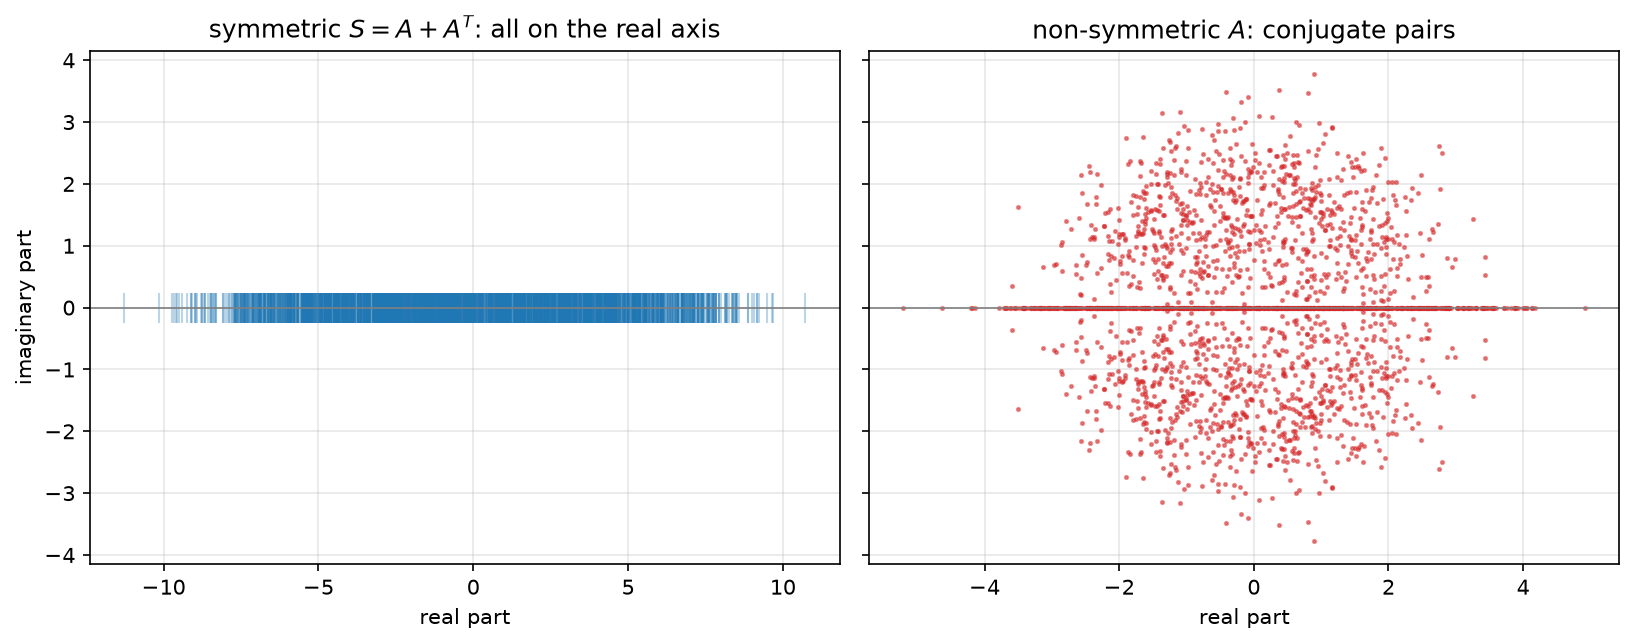

Figure 01g.5 saved as Revision/textbook/figures/01g_5_random_spectra.png


In [9]:
symmetric_all = np.concatenate(symmetric_spectra)
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.4), sharey=True)
left.plot(symmetric_all, np.zeros_like(symmetric_all), "|", color="tab:blue",
          ms=14, alpha=0.3)
left.set_title("symmetric $S = A + A^T$: all on the real axis")
right.plot(general_all.real, general_all.imag, ".", color="tab:red", ms=3,
           alpha=0.5)
right.set_title("non-symmetric $A$: conjugate pairs")
for ax in (left, right):
    ax.axhline(0.0, color="0.5", lw=0.8)
    ax.set_xlabel("real part")
left.set_ylabel("imaginary part")
fig.tight_layout()
save_figure(fig, "random_spectra",
            "The eigenvalues of 300 random real $8 \\times 8$ matrices in the "
            "complex plane (horizontal axis real part, vertical axis imaginary "
            "part, pure numbers). Left: the symmetric matrices $S = A + A^T$; "
            "every one of the 2400 eigenvalues lies on the real axis (blue "
            "strokes). Right: the non-symmetric matrices $A$ (red dots); many "
            "eigenvalues are complex, and the picture is mirror-symmetric in the "
            "real axis because complex eigenvalues of a real matrix come in "
            "conjugate pairs.")

## 9. The signature and Sylvester's law of inertia

A symmetric matrix $S$ defines the quadratic form $Q(v) = v^T S v$. For the
frame metric, $Q(v) = \eta_{ab} v^a v^b$ is the squared length of notebook
01e. In the eigenvector coordinates $v = O w$ (the columns of $O$ are the
eigenvectors of $S$) it becomes $Q = \lambda_1 w_1^2 + \dots + \lambda_n
w_n^2$, because $O^T S O = \Lambda$. So the **signature** $(p, q)$, the
numbers of positive and negative eigenvalues, says in how many perpendicular
directions $Q$ is positive and in how many negative.

A change of coordinates $v = P w$ with an invertible matrix $P$ gives
$Q = w^T (P^T S P) w$: the matrix of the form becomes $P^T S P$. Its
eigenvalues are different, but **Sylvester's law of inertia** says that the
signature is the same. The reason in words: let $S$ have $p$ and $P^T S P$
have $p'$ positive eigenvalues, and suppose $p' < p$. On every nonzero
combination of the $p$ eigenvectors of $S$ with positive eigenvalues,
$Q > 0$. On every combination of the $n - p'$ vectors $P u$, where $u$ runs
through the eigenvectors of $P^T S P$ with eigenvalues $\leq 0$, $Q \leq 0$.
Together these are $p + n - p' > n$ vectors in $n$-dimensional space, so a
nonzero combination of the first kind equals a combination of the second
kind, and on that vector $Q > 0$ and $Q \leq 0$ at once, which is
impossible. So $p' \geq p$; exchanging the roles of the two matrices gives
$p \geq p'$, and the same argument for $-S$ counts the negative eigenvalues.
So the signature (4,4) of the author's spacetime is a property of the
spacetime, not of the coordinates used to describe it.

The next cell reads $\eta$ from the Revision record, finds its eigenvalues
(for a diagonal matrix: its diagonal entries) and its signature, and checks the
law on 2000 random invertible matrices $P$ (it also makes sure that no
eigenvalue is so close to 0 that rounding could change its sign: each must be
larger than 1000 times the rounding error, $2.2 \times 10^{-16}$ times the
largest size). Then it reads the author's metric
from the record and counts the signs of its eigenvalues on a grid of 61 values
of $a_4$ from $-3$ to 3 and 50 values of $z$ in $(0, \pi/2)$; their product
must be $\det g = \cos^2 z > 0$.

In [10]:
algebra = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
names = algebra["coordinates"]  # ["x1", ..., "x8"]
eta = algebra["eta"]  # the diagonal of the frame metric
eta_matrix = np.diag(np.array(eta, dtype=float))
eta_values = np.linalg.eigvalsh(eta_matrix)  # eigenvalues from the smallest up
signature = (int((eta_values > 0).sum()), int((eta_values < 0).sum()))
say(f"eigenvalues of eta: {eta_values.tolist()}; signature {signature}")
algebra_report = json.loads(repository_file(
    "Revision/algebra/reports/python-algebra.json").read_text(encoding="utf-8"))
verdicts = {c["name"]: c["verdict"] for c in algebra_report["checks"]}
check(signature == (4, 4) and verdicts["coordinate_map"] == "pass",
      "eta has 4 positive and 4 negative eigenvalues: the signature (4,4)",
      record="Revision/algebra/reports/python-algebra.json, check coordinate_map")
sylvester_counts = set()
smallest_size, largest_size = np.inf, 0.0
transformed_spectra = []
for trial in range(2000):
    P = generator.normal(size=(8, 8))  # a random matrix (invertible: det != 0)
    changed = np.linalg.eigvalsh(P.T @ eta_matrix @ P)
    sylvester_counts.add((int((changed > 0).sum()), int((changed < 0).sum())))
    smallest_size = min(smallest_size, float(np.min(np.abs(changed))))
    largest_size = max(largest_size, float(np.max(np.abs(changed))))
    if trial < 40:
        transformed_spectra.append(changed)
say(f"signatures of P^T eta P found: {sorted(sylvester_counts)}; eigenvalue "
    f"sizes from {smallest_size:.1e} to {largest_size:.1f}")
# Rounding changes an eigenvalue by about 2.2e-16 times the largest size; the
# signs are reliable if the smallest size is far above that.
reliable = smallest_size > 1000 * 2.2e-16 * largest_size
check(sylvester_counts == {(4, 4)} and reliable, "Sylvester: P^T eta P has the "
      "signature (4,4) for all 2000 random P, although its eigenvalues change")

eigenvalues of eta: [-1.0, -1.0, -1.0, -1.0, 1.0, 1.0, 1.0, 1.0]; signature (4, 4)
PASS eta has 4 positive and 4 negative eigenvalues: the signature (4,4)
     reproduces Revision/algebra/reports/python-algebra.json, check coordinate_map
signatures of P^T eta P found: [(4, 4)]; eigenvalue sizes from 1.2e-08 to 37.1
PASS Sylvester: P^T eta P has the signature (4,4) for all 2000 random P, although its
    eigenvalues change


The next cell reads the author's metric from the record (as in notebook 01a),
evaluates its eight eigenvalues on the grid and checks their signs and their
product.

In [11]:
a4 = sp.Symbol("a4", real=True)  # the value of a4(x4) at one time
z = sp.Symbol("z", positive=True)  # z = 6 H x8, between 0 and pi/2
curvature = json.loads(repository_file("Revision/gkd_lovelock/results/curvature.json")
                       .read_text(encoding="utf-8"))


def from_record(text):
    """The record's Mathematica text as a sympy expression."""
    text = text.replace("a4[x4]", "a4").replace("Sin[6*H*x8]", "sin(z)")
    text = text.replace("Cot[6*H*x8]", "cot(z)").replace("^", "**")
    return sp.sympify(text, locals={"a4": a4, "z": z, "E": sp.E})


g_record = [from_record(text) for text in curvature["metricDiagonal"]]
metric_numbers = sp.lambdify((a4, z), g_record, "numpy")  # a4, z -> 8 numbers
signs_ok, product_error = True, 0.0
for a4_value in np.linspace(-3.0, 3.0, 61):
    for z_value in np.linspace(0.05, np.pi / 2 - 0.05, 50):
        g_values = np.linalg.eigvalsh(np.diag(np.array(
            metric_numbers(a4_value, z_value), dtype=float)))
        signs_ok &= (int((g_values > 0).sum()), int((g_values < 0).sum())) == (4, 4)
        product_error = max(product_error,
                            abs(np.prod(g_values) - np.cos(z_value) ** 2))
check(signs_ok, "the author's metric has the signature (4,4) at all 3050 grid "
      "points (a4, z)")
lovelock_report = json.loads(repository_file(
    "Revision/gkd_lovelock/results/python-lovelock-report.json")
    .read_text(encoding="utf-8"))
root_verdict = {c["name"]: c["verdict"]
                for c in lovelock_report["checks"]}["sqrt_abs_det_g"]
check(product_error < 1e-12 and root_verdict == "PASS",
      "the product of the eight eigenvalues is det g = cos(z)^2 at every grid point",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, check "
             "sqrt_abs_det_g")

PASS the author's metric has the signature (4,4) at all 3050 grid points (a4, z)
PASS the product of the eight eigenvalues is det g = cos(z)^2 at every grid point
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, check
    sqrt_abs_det_g


The next cell draws both results. Left: the eight eigenvalues of
$P^T \eta P$ for 40 random $P$ (one column per $P$). Right: the eight
eigenvalues of the author's metric at $z = 0.9$ against $a_4$. Both vertical
axes are *symmetric logarithmic*: linear in a small band around 0 (between
$-0.001$ and 0.001 on the left, between $-0.1$ and 0.1 on the right) and
logarithmic outside, so that large and small values of both signs fit.

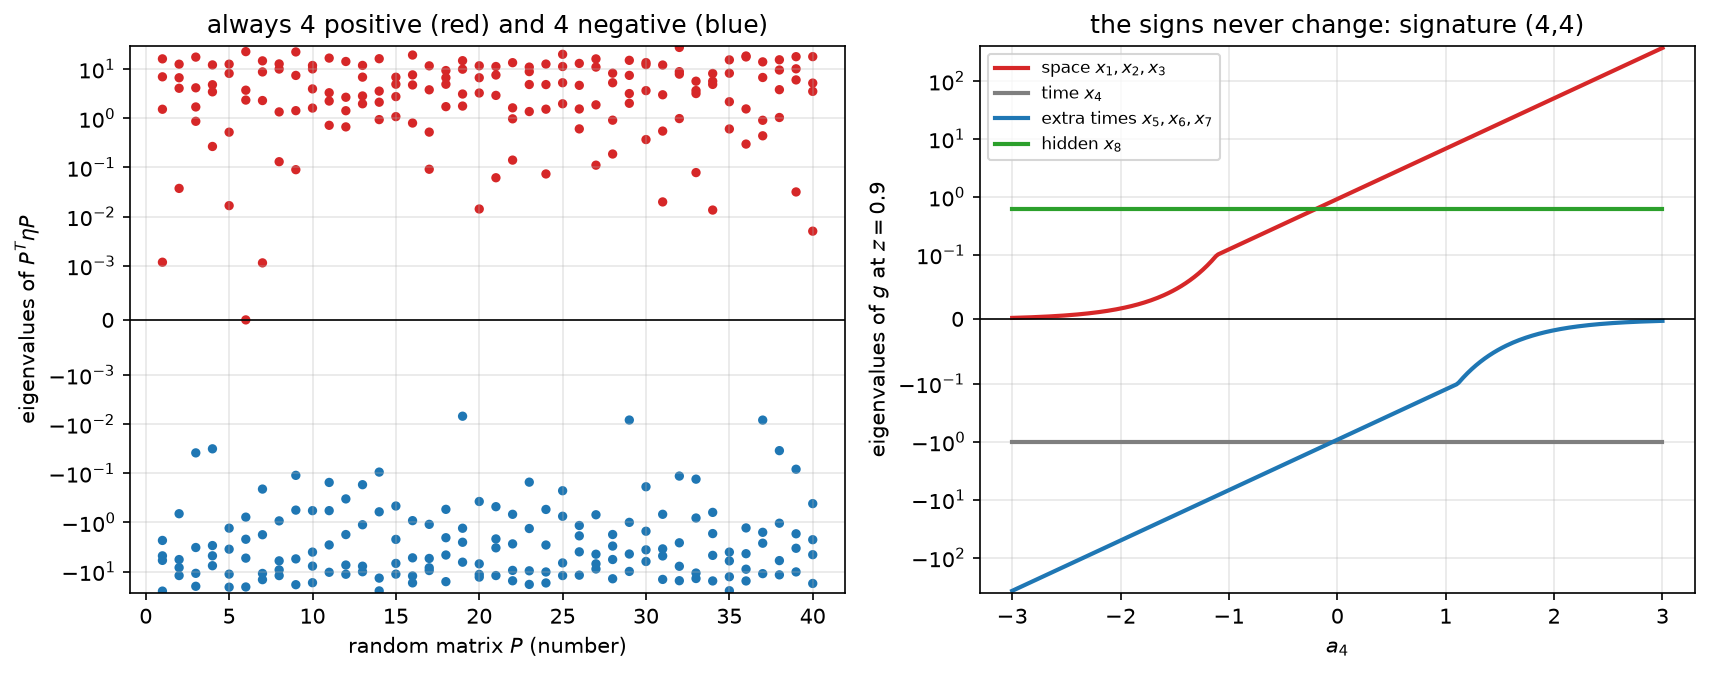

Figure 01g.6 saved as Revision/textbook/figures/01g_6_signature.png


In [12]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.6))
for column, spectrum in enumerate(transformed_spectra):
    colors_column = ["tab:red" if value > 0 else "tab:blue" for value in spectrum]
    left.scatter(np.full(8, column + 1), spectrum, c=colors_column, s=12)
left.axhline(0.0, color="black", lw=0.8)
left.set_yscale("symlog", linthresh=0.001)  # linear between -0.001 and 0.001
left.set_xlabel("random matrix $P$ (number)")
left.set_ylabel("eigenvalues of $P^T \\eta P$")
left.set_title("always 4 positive (red) and 4 negative (blue)")
a4_line = np.linspace(-3.0, 3.0, 301)
curves = np.array([metric_numbers(value, 0.9) for value in a4_line], dtype=float)
styles = [("tab:red", "space $x_1, x_2, x_3$", 0), ("tab:gray", "time $x_4$", 3),
          ("tab:blue", "extra times $x_5, x_6, x_7$", 4),
          ("tab:green", "hidden $x_8$", 7)]
for color, label, index in styles:
    right.plot(a4_line, curves[:, index], color=color, lw=2, label=label)
right.axhline(0.0, color="black", lw=0.8)
right.set_yscale("symlog", linthresh=0.1)
right.set_xlabel("$a_4$")
right.set_ylabel("eigenvalues of $g$ at $z = 0.9$")
right.set_title("the signs never change: signature (4,4)")
right.legend(fontsize=8, loc="upper left")
fig.tight_layout()
# how many of the 320 drawn eigenvalues are smaller than 0.001 in size
tiny = sum(int((np.abs(spectrum) < 0.001).sum()) for spectrum in transformed_spectra)
tiny_text = "the one eigenvalue" if tiny == 1 else f"the {tiny} eigenvalues"
tiny_verb = "sits" if tiny == 1 else "sit"  # singular or plural
save_figure(fig, "signature",
            "Left: the eight eigenvalues of $P^T \\eta P$ for 40 random matrices "
            "$P$ (one column of dots per matrix; red positive, blue negative); "
            "the values change from matrix to matrix, but every column has four "
            "positive and four negative eigenvalues (Sylvester's law of inertia); "
            f"{tiny_text} smaller than 0.001 in size {tiny_verb} on the zero "
            "line, but none is zero. "
            "Right: the eigenvalues of the author's metric $g$ at $z = 6 H x_8 = "
            "0.9$ against $a_4$: the three space entries $e^{2a_4} s$ (red, "
            "growing), the time entry $-1$ (grey), the three extra-time entries "
            "$-e^{-2a_4} s$ (blue, shrinking towards 0 as the extra times deflate, "
            "but never crossing it) and the hidden entry $\\cot^2 z$ (green). The "
            "vertical axes are linear near 0 (between $-0.001$ and 0.001 on the "
            "left, $-0.1$ and 0.1 on the right) and logarithmic outside; all "
            "quantities are pure numbers.")

## 10. The eigenvalues of the gamma matrices

The eight real gamma matrices of the Revision record obey
$(\gamma^a)^2 = \eta^{aa} I$ (the Clifford relation with equal indices). If
$\gamma^a v = \lambda v$, then, line by line,

$$(\gamma^a)^2 v = \gamma^a(\lambda v) = \lambda\,\gamma^a v = \lambda^2 v$$

(apply $\gamma^a$ twice; a number can be moved in front), and also
$(\gamma^a)^2 v = \eta^{aa} v$. So $\lambda^2 = \eta^{aa}$:
$\lambda = \pm 1$ for the space-like directions $x_1, x_2, x_3, x_8$ and
$\lambda = \pm i$ for the time-like directions $x_4, \dots, x_7$.

How many of each? The trace is 0: for any $b \neq a$,
$\mathrm{tr}\,\gamma^a = \eta^{bb}\,\mathrm{tr}(\gamma^b\gamma^b\gamma^a)$
(insert $\eta^{bb}(\gamma^b)^2 = \eta^{bb}\eta^{bb} I = I$),
$= \eta^{bb}\,\mathrm{tr}(\gamma^b\gamma^a\gamma^b)$ (the trace does not
change when the first factor is moved to the end),
$= -\eta^{bb}\,\mathrm{tr}(\gamma^b\gamma^b\gamma^a)$ (the anticommutation
$\gamma^a\gamma^b = -\gamma^b\gamma^a$), $= -\mathrm{tr}\,\gamma^a$. A number
equal to its own negative is 0. The trace is the sum of the 16 eigenvalues, so
$+1$ and $-1$ (or $+i$ and $-i$) occur 8 times each: the characteristic
polynomial is $(\lambda^2 - \eta^{aa})^8$.

More generally, for any vector $v$ the matrix $\gamma(v) = v_a\gamma^a$ (with
$v_a = \eta_{ab} v^b$) squares to $\gamma(v)^2 = v_a v_b \gamma^a \gamma^b =
\tfrac12 v_a v_b (\gamma^a\gamma^b + \gamma^b\gamma^a) = v_a v_b \eta^{ab} I =
Q(v)\, I$ (only the symmetric part of $\gamma^a\gamma^b$ counts, notebook 01e),
so its eigenvalues are $\pm\sqrt{Q(v)}$: real for a space-like, imaginary for a
time-like and 0 for a light-like $v$. A light-like $v$ gives a *nilpotent*
matrix: $\gamma(v) \neq 0$ but $\gamma(v)^2 = 0$. The next cell checks all of
this with the matrices of the record.

In [13]:
gamma = [np.array(matrix, dtype=int) for matrix in algebra["gamma"]]  # gamma^a
polynomials_ok, traces_ok, numeric_ok = True, True, True
for name, eta_aa, g_a in zip(names, eta, gamma):
    poly = sp.Matrix(g_a.tolist()).charpoly(lam).as_expr()  # det(lambda I - g_a)
    polynomials_ok &= sp.expand(poly - (lam ** 2 - eta_aa) ** 8) == 0
    traces_ok &= int(np.trace(g_a)) == 0
    found = np.linalg.eigvals(g_a.astype(float))
    if eta_aa == 1:  # space-like: +1 and -1, eight times each
        numeric_ok &= bool(np.allclose(np.sort(found.real), [-1] * 8 + [1] * 8)
                           and np.allclose(found.imag, 0))
    else:  # time-like: +i and -i, eight times each
        numeric_ok &= bool(np.allclose(found.real, 0)
                           and np.allclose(np.sort(found.imag), [-1] * 8 + [1] * 8))
    say(f"gamma^({name}): eta {eta_aa:+d}, trace {int(np.trace(g_a))}, "
        f"characteristic polynomial {sp.factor(poly)}")
check(traces_ok and polynomials_ok,
      "every gamma^a has trace 0 and the characteristic polynomial "
      "(lambda^2 - eta_aa)^8", record="Revision/algebra/reports/python-algebra.json, "
      "check clifford_relation (the relations with equal indices)")
check(numeric_ok and verdicts["symmetry_pattern"] == "pass",
      "numpy: +1 and -1 (x1, x2, x3, x8: symmetric matrices) or +i and -i "
      "(x4 ... x7: antisymmetric matrices), 8 times each",
      record="Revision/algebra/reports/python-algebra.json, check symmetry_pattern")

gamma^(x1): eta +1, trace 0, characteristic polynomial (lambda - 1)**8*(lambda + 1)**8
gamma^(x2): eta +1, trace 0, characteristic polynomial (lambda - 1)**8*(lambda + 1)**8
gamma^(x3): eta +1, trace 0, characteristic polynomial (lambda - 1)**8*(lambda + 1)**8
gamma^(x4): eta -1, trace 0, characteristic polynomial (lambda**2 + 1)**8
gamma^(x5): eta -1, trace 0, characteristic polynomial (lambda**2 + 1)**8
gamma^(x6): eta -1, trace 0, characteristic polynomial (lambda**2 + 1)**8
gamma^(x7): eta -1, trace 0, characteristic polynomial (lambda**2 + 1)**8
gamma^(x8): eta +1, trace 0, characteristic polynomial (lambda - 1)**8*(lambda + 1)**8
PASS every gamma^a has trace 0 and the characteristic polynomial (lambda^2 - eta_aa)^8
     reproduces Revision/algebra/reports/python-algebra.json, check clifford_relation
    (the relations with equal indices)
PASS numpy: +1 and -1 (x1, x2, x3, x8: symmetric matrices) or +i and -i (x4 ... x7:
    antisymmetric matrices), 8 times each
     reproduces Re

The next cell builds $\gamma(v)$ for four vectors: the unit vectors along $x_1$
($Q = 1$) and $x_5$ ($Q = -1$), their sum ($Q = 0$, light-like) and
$v = (1, 2, \dots, 8)$ ($Q = -48$, notebook 01e). It checks
$\gamma(v)^2 = Q(v) I$ exactly with whole numbers, the eigenvalues
$\pm\sqrt{Q}$ with numpy, and for the light-like vector that $\gamma(v)$ is
not zero but squares to zero and has the characteristic polynomial
$\lambda^{16}$ (computed exactly with sympy: numpy is not reliable for a
nilpotent matrix, whose eigenvectors do not fill the space). Then it repeats
the square rule for 100 random vectors with whole-number components.

In [14]:
def gamma_of(vector):
    """gamma(v) = v_a gamma^a with v_a = eta_ab v^b (whole numbers)."""
    lowered = [eta[a] * int(vector[a]) for a in range(8)]
    return sum(lowered[a] * gamma[a] for a in range(8))


def squared_length(vector):
    """Q(v) = eta_ab v^a v^b."""
    return sum(eta[a] * int(vector[a]) ** 2 for a in range(8))


unit = np.eye(8, dtype=int)
examples = [("e(x1)", unit[0]), ("e(x5)", unit[4]), ("e(x1) + e(x5)", unit[0] + unit[4]),
            ("(1, 2, ..., 8)", np.arange(1, 9))]
example_spectra = {}
squares_ok, nilpotent_ok = True, True
for label, vector in examples:
    matrix = gamma_of(vector)
    q = squared_length(vector)
    squares_ok &= bool((matrix @ matrix == q * np.eye(16, dtype=int)).all())
    if q == 0:  # light-like: exact answer from sympy
        poly = sp.Matrix(matrix.tolist()).charpoly(lam).as_expr()
        nilpotent_ok &= poly == lam ** 16 and bool(np.count_nonzero(matrix) > 0)
        example_spectra[label] = np.zeros(16, dtype=complex)
    else:
        example_spectra[label] = np.linalg.eigvals(matrix.astype(float))
        target = np.sqrt(complex(q))  # sqrt(Q), imaginary for Q < 0
        # count the eigenvalues within 1e-9 of +sqrt(Q) and of -sqrt(Q)
        near_plus = int((np.abs(example_spectra[label] - target) < 1e-9).sum())
        near_minus = int((np.abs(example_spectra[label] + target) < 1e-9).sum())
        squares_ok &= near_plus == 8 and near_minus == 8
    say(f"v = {label}: Q(v) = {q}, gamma(v)^2 = Q(v) I")
for _ in range(100):  # random vectors with whole-number components -5 ... 5
    vector = generator.integers(-5, 6, size=8)
    matrix = gamma_of(vector)
    squares_ok &= bool((matrix @ matrix
                        == squared_length(vector) * np.eye(16, dtype=int)).all())
check(squares_ok, "gamma(v)^2 = Q(v) I exactly and the eigenvalues are +-sqrt(Q(v)) "
      "(4 examples and 100 random vectors)")
check(nilpotent_ok, "a light-like v gives a nilpotent gamma(v): not zero, square "
      "zero, characteristic polynomial lambda^16")

v = e(x1): Q(v) = 1, gamma(v)^2 = Q(v) I
v = e(x5): Q(v) = -1, gamma(v)^2 = Q(v) I
v = e(x1) + e(x5): Q(v) = 0, gamma(v)^2 = Q(v) I
v = (1, 2, ..., 8): Q(v) = -48, gamma(v)^2 = Q(v) I
PASS gamma(v)^2 = Q(v) I exactly and the eigenvalues are +-sqrt(Q(v)) (4 examples and 100
    random vectors)
PASS a light-like v gives a nilpotent gamma(v): not zero, square zero, characteristic
    polynomial lambda^16


The next cell draws the eigenvalues of the eight gamma matrices (left) and of
the four matrices $\gamma(v)$ (right) in the complex plane.

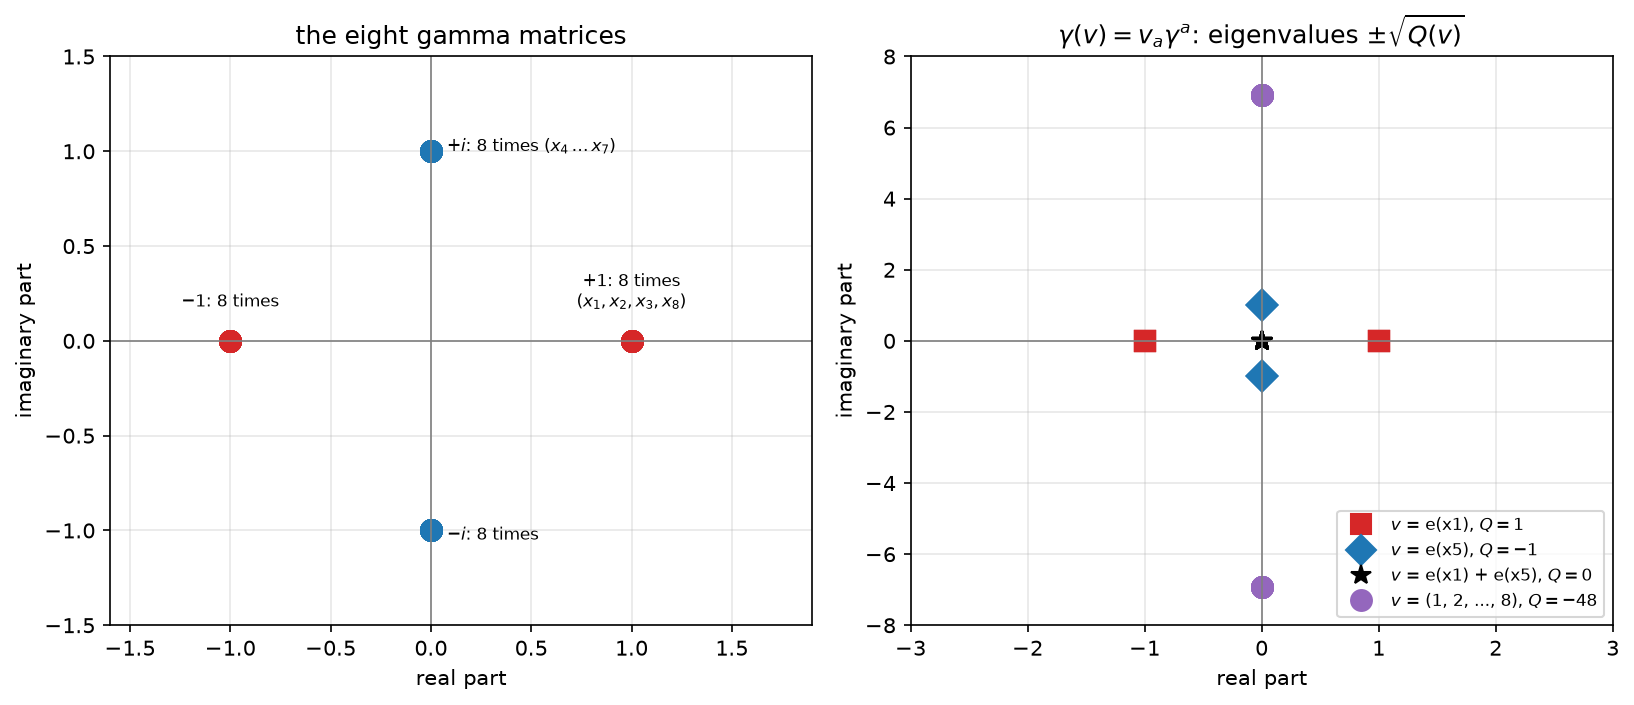

Figure 01g.7 saved as Revision/textbook/figures/01g_7_gamma_eigenvalues.png


In [15]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.8))
for name, eta_aa, g_a in zip(names, eta, gamma):
    found = np.linalg.eigvals(g_a.astype(float))
    color = "tab:red" if eta_aa == 1 else "tab:blue"
    left.plot(found.real, found.imag, "o", color=color, ms=10, alpha=0.3)
left.text(1.0, 0.18, "$+1$: 8 times\n($x_1, x_2, x_3, x_8$)", ha="center",
          fontsize=8)
left.text(-1.0, 0.18, "$-1$: 8 times", ha="center", fontsize=8)
left.text(0.08, 1.0, "$+i$: 8 times ($x_4 \\dots x_7$)", fontsize=8)
left.text(0.08, -1.05, "$-i$: 8 times", fontsize=8)
left.set_xlim(-1.6, 1.9)
left.set_ylim(-1.5, 1.5)
left.set_title("the eight gamma matrices")
markers = {"e(x1)": ("s", "tab:red"), "e(x5)": ("D", "tab:blue"),
           "e(x1) + e(x5)": ("*", "black"), "(1, 2, ..., 8)": ("o", "tab:purple")}
for label, spectrum in example_spectra.items():
    shape, color = markers[label]
    right.plot(spectrum.real, spectrum.imag, shape, color=color, ms=10,
               label=f"$v$ = {label}, $Q = {squared_length(dict(examples)[label])}$")
right.set_xlim(-3.0, 3.0)
right.set_ylim(-8.0, 8.0)
right.set_title("$\\gamma(v) = v_a \\gamma^a$: eigenvalues $\\pm\\sqrt{Q(v)}$")
right.legend(fontsize=8, loc="lower right")
for ax in (left, right):
    ax.axhline(0.0, color="0.5", lw=0.8)
    ax.axvline(0.0, color="0.5", lw=0.8)
    ax.set_xlabel("real part")
    ax.set_ylabel("imaginary part")
fig.tight_layout()
save_figure(fig, "gamma_eigenvalues",
            "Eigenvalues in the complex plane (horizontal axis real part, vertical "
            "axis imaginary part, pure numbers). Left: the 16 eigenvalues of each "
            "of the eight real gamma matrices of the Revision record: $\\pm 1$, "
            "eight times each, for the space-like $x_1, x_2, x_3, x_8$ (red) and "
            "$\\pm i$, eight times each, for the time-like $x_4$ to $x_7$ (blue). "
            "Right: the eigenvalues of $\\gamma(v) = v_a \\gamma^a$ for four "
            "vectors: $\\pm 1$ for the unit vector along $x_1$ ($Q = 1$), "
            "$\\pm i$ along $x_5$ ($Q = -1$), only 0 for the light-like sum of "
            "the two ($Q = 0$, black star) and $\\pm i\\sqrt{48}$ for "
            "$v = (1, 2, \\dots, 8)$ ($Q = -48$).")

## 11. A Hermitian matrix of the record: B and its signature (8,8)

The record stores the matrix $B = -i\, C\gamma^{(x_4)}$, where
$C = \gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_2)}\gamma^{(x_3)}$ is real. $B$ is
complex: its real part is 0, its imaginary part a real $16 \times 16$ matrix of
entries $-1$, 0, 1. In the theory of the course $B$ gives the charge density
$J^{(x_4)} = \Psi^\dagger B \Psi$ of the fields. Its properties, line by line:

- $B$ is Hermitian ($B^\dagger = B$); for a matrix $iA$ with real $A$ this
  means $(iA)^\dagger = -i A^T = iA$, that is $A^T = -A$: the imaginary part is
  antisymmetric. By section 8 its eigenvalues are real.
- $B^2 = I$, so as in section 10 every eigenvalue has $\lambda^2 = 1$:
  $\lambda = \pm 1$.
- $\mathrm{tr}\,B = 0$, so $+1$ and $-1$ occur 8 times each: the signature
  (8,8), and the characteristic polynomial is $(\lambda - 1)^8(\lambda + 1)^8$.

Because half of the eigenvalues of $B$ are negative, the charge
$\Psi^\dagger B \Psi$ can be positive or negative: the record calls it an
indefinite form, and for the quantised field it leads to an indefinite
(Krein) state space. The next cell checks the four properties exactly with
sympy and with numpy (`eigh` also works for Hermitian matrices; its
eigenvectors are perpendicular in the sense $u^\dagger w = 0$).

In [16]:
B = sp.Matrix(algebra["B"]["re"]) + sp.I * sp.Matrix(algebra["B"]["im"])
C = sp.Matrix(algebra["C"])
check(B == -sp.I * C * sp.Matrix(algebra["gamma"][3]),
      "the record's B equals -i C gamma^(x4) computed from its C and gamma^(x4)")
poly_B = sp.factor(B.charpoly(lam).as_expr())
real_part_zero = sp.Matrix(algebra["B"]["re"]).is_zero_matrix  # True or False
say(f"B: real part zero {real_part_zero}, trace {B.trace()}, characteristic "
    f"polynomial {poly_B}")
check(B.H == B and B * B == sp.eye(16) and B.trace() == 0
      and sp.expand(poly_B - (lam - 1) ** 8 * (lam + 1) ** 8) == 0,
      "B is Hermitian, B^2 = I, tr B = 0, characteristic polynomial "
      "(lambda - 1)^8 (lambda + 1)^8: the signature (8,8)",
      record="Revision/algebra/reports/python-algebra.json, check "
             "B_hermitian_involution_signature")
B_numbers = np.array(B.tolist(), dtype=complex)
values_B, vectors_B = np.linalg.eigh(B_numbers)
unitary_error = float(np.max(np.abs(vectors_B.conj().T @ vectors_B - np.eye(16))))
say(f"numpy eigh: eigenvalues {values_B.round(12).tolist()}")
theory = json.loads(repository_file(
    "Revision/theory/reports/python-field-theory.json").read_text(encoding="utf-8"))
theory_verdict = {c["name"]: c["verdict"] for c in theory["checks"]}["B_properties"]
krein_entry = theory["formulas"]["quantisation"]["krein"]  # a sentence of the record
say(f"the record's quantisation entry: {krein_entry}")
check(np.allclose(values_B, [-1.0] * 8 + [1.0] * 8, rtol=0, atol=1e-12)
      and unitary_error < 1e-12 and theory_verdict == "pass",
      "numpy: eight eigenvalues -1 and eight +1, perpendicular eigenvectors",
      record="Revision/theory/reports/python-field-theory.json, check B_properties")

PASS the record's B equals -i C gamma^(x4) computed from its C and gamma^(x4)
B: real part zero True, trace 0, characteristic polynomial (lambda - 1)**8*(lambda +
    1)**8
PASS B is Hermitian, B^2 = I, tr B = 0, characteristic polynomial (lambda - 1)^8 (lambda
    + 1)^8: the signature (8,8)
     reproduces Revision/algebra/reports/python-algebra.json, check
    B_hermitian_involution_signature
numpy eigh: eigenvalues [-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 1.0, 1.0, 1.0,
    1.0, 1.0, 1.0, 1.0, 1.0]
the record's quantisation entry: B Hermitian, B^2 = 1, signature (8,8): indefinite
    (Krein) state space
PASS numpy: eight eigenvalues -1 and eight +1, perpendicular eigenvectors
     reproduces Revision/theory/reports/python-field-theory.json, check B_properties


The next cell draws the imaginary part of $B$ as a heat map and the 16
eigenvalues of $B$ in order.

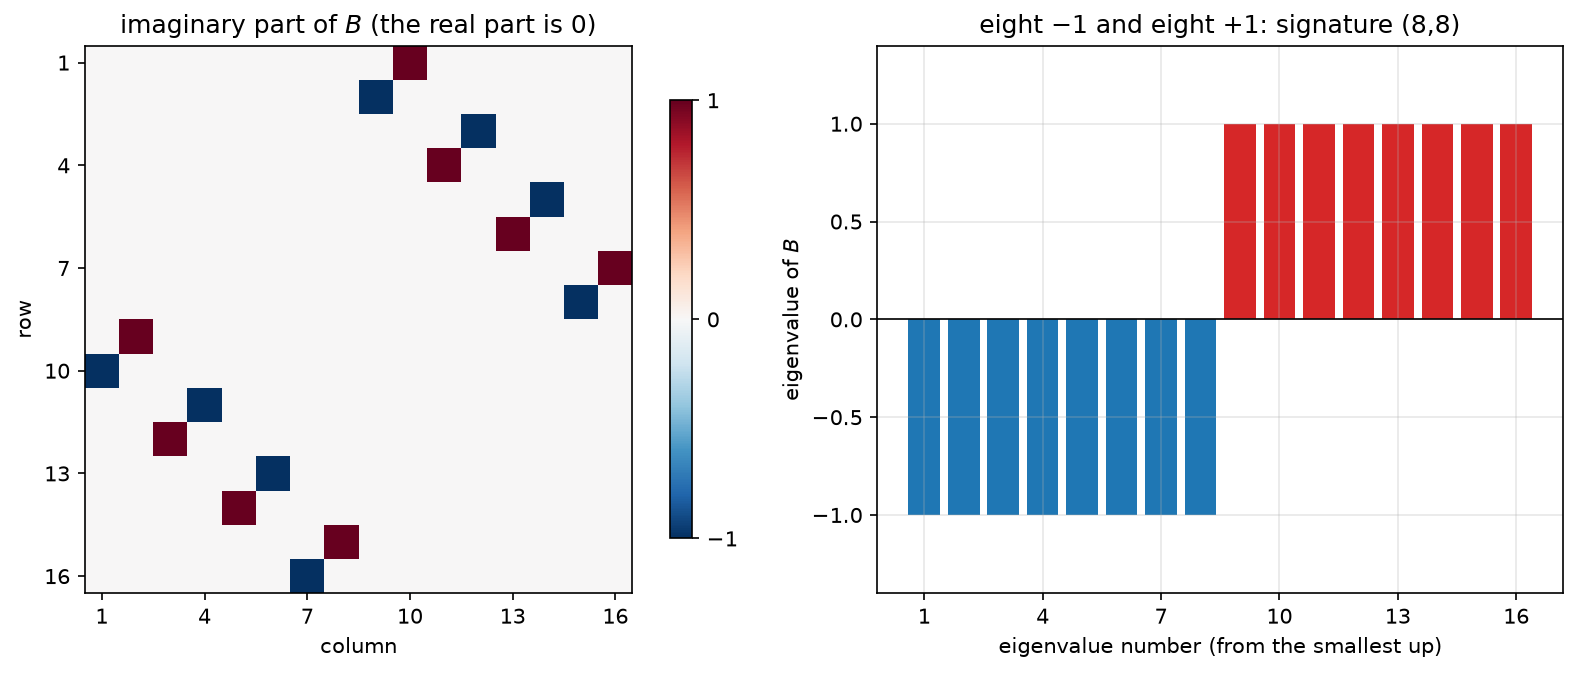

Figure 01g.8 saved as Revision/textbook/figures/01g_8_hermitian_b.png


In [17]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.6),
                                  gridspec_kw={"width_ratios": [1.1, 1]})
image = left.imshow(B_numbers.imag, cmap="RdBu_r", vmin=-1, vmax=1)
left.grid(False)
ticks = range(0, 16, 3)
left.set_xticks(ticks, [str(t + 1) for t in ticks])
left.set_yticks(ticks, [str(t + 1) for t in ticks])
left.set_xlabel("column")
left.set_ylabel("row")
left.set_title("imaginary part of $B$ (the real part is 0)")
fig.colorbar(image, ax=left, shrink=0.8, ticks=[-1, 0, 1])
right.bar(np.arange(1, 17), values_B,
          color=["tab:blue" if value < 0 else "tab:red" for value in values_B])
right.axhline(0.0, color="black", lw=0.8)
right.set_xticks(range(1, 17, 3))
right.set_ylim(-1.4, 1.4)
right.set_xlabel("eigenvalue number (from the smallest up)")
right.set_ylabel("eigenvalue of $B$")
right.set_title("eight $-1$ and eight $+1$: signature (8,8)")
fig.tight_layout()
save_figure(fig, "hermitian_b",
            "Left: heat map of the imaginary part of the Hermitian matrix "
            "$B = -i C\\gamma^{(x_4)}$ of the Revision record (rows and columns 1 "
            "to 16; red $+1$, blue $-1$, white 0; its real part is 0). The picture "
            "changes sign when mirrored in the diagonal: the imaginary part is "
            "antisymmetric, which makes $B$ Hermitian. Right: the 16 eigenvalues "
            "of $B$ from the smallest up (pure numbers): eight times $-1$ (blue) "
            "and eight times $+1$ (red), the signature (8,8).")

## 12. How a computer finds an eigenvalue: power iteration

A computer does not find eigenvalues as the roots of $\det(M - \lambda I)$
(that polynomial is very sensitive to rounding for large matrices); it
transforms the matrix step by step. The simplest such method is **power
iteration**. Write a starting vector as a sum of eigenvectors,
$x_0 = c_1 u_1 + c_2 u_2 + \dots$, with $|\lambda_1| > |\lambda_2| \geq \dots$.
Multiplying by $M$ $k$ times gives

$$M^k x_0 = c_1 \lambda_1^k u_1 + c_2 \lambda_2^k u_2 + \dots =
\lambda_1^k\Big(c_1 u_1 + c_2 (\lambda_2/\lambda_1)^k u_2 + \dots\Big)$$

(each eigenvector is only multiplied by its eigenvalue; then $\lambda_1^k$ is
taken out), so the direction approaches $u_1$, and the error shrinks by the
factor $|\lambda_2/\lambda_1|$ in each step. Rescaling to length 1 after each
step keeps the numbers from growing. The next cell runs 40 steps from
$x_0 = (1, 0)$ for the matrix $M$ of section 5 (factor $1/3$) and from
$(1, 0, 0)$ for $T_3$ of section 6 (factor $2/(2 + \sqrt 2) = 2 - \sqrt 2
\approx 0.586$), measures the distance to the true eigenvector and checks the
factor.

M (2 x 2): |lambda2/lambda1| = 0.333333, measured factors 0.333333 to 0.333333
T3 (3 x 3): |lambda2/lambda1| = 0.585786, measured factors 0.585786 to 0.585789
PASS power iteration: each step shrinks the error by |lambda2/lambda1| (1/3 for M, 2 -
    sqrt 2 for T3)


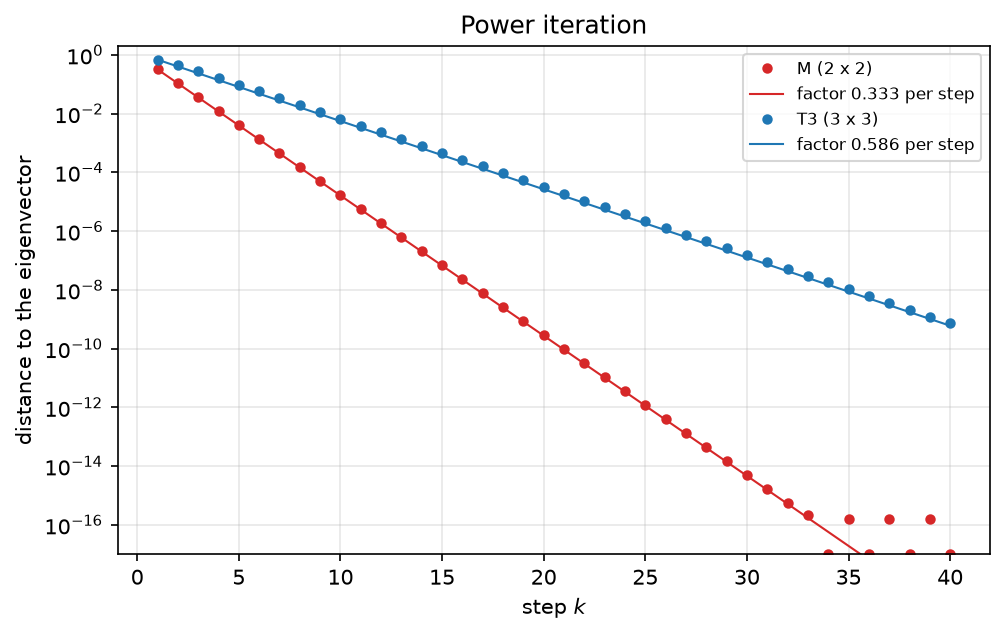

Figure 01g.9 saved as Revision/textbook/figures/01g_9_power_iteration.png


In [18]:
def power_iteration(matrix, start, steps):
    """Multiply by matrix and rescale to length 1, steps times; return the
    distances to the eigenvector of the largest eigenvalue after each step."""
    values_m, vectors_m = np.linalg.eigh(matrix)
    top = vectors_m[:, -1]  # the eigenvector of the largest eigenvalue
    x = np.array(start, dtype=float)
    distances = []
    for _ in range(steps):
        x = matrix @ x
        x = x / np.sqrt(x @ x)  # rescale to length 1
        aligned = top if x @ top > 0 else -top  # the sign of an eigenvector is free
        distances.append(float(np.sqrt(((x - aligned) ** 2).sum())))
    return np.array(distances), abs(values_m[-2] / values_m[-1])


runs = {"M (2 x 2)": power_iteration(M_numbers, [1, 0], 40),
        "T3 (3 x 3)": power_iteration(np.array(T3.tolist(), dtype=float),
                                      [1, 0, 0], 40)}
factors_ok = True
for label, (distances, ratio) in runs.items():
    measured = distances[11:21] / distances[10:20]  # steps 11 to 20
    say(f"{label}: |lambda2/lambda1| = {ratio:.6f}, measured factors "
        f"{measured.min():.6f} to {measured.max():.6f}")
    factors_ok &= bool(np.all(np.abs(measured - ratio) < 1e-3))
check(factors_ok, "power iteration: each step shrinks the error by |lambda2/lambda1|"
      " (1/3 for M, 2 - sqrt 2 for T3)")
fig, ax = plt.subplots(figsize=(7.5, 4.4))
steps_axis = np.arange(1, 41)
for (label, (distances, ratio)), color in zip(runs.items(), ("tab:red", "tab:blue")):
    # a distance 0 (exact agreement) is drawn at 1e-17, the bottom of the axis
    ax.semilogy(steps_axis, np.maximum(distances, 1e-17), "o", color=color, ms=4,
                label=label)
    ax.semilogy(steps_axis, distances[0] * ratio ** (steps_axis - 1), "-",
                color=color, lw=1, label=f"factor {ratio:.3f} per step")
ax.set_ylim(1e-17, 2.0)
ax.set_xlabel("step $k$")
ax.set_ylabel("distance to the eigenvector")
ax.set_title("Power iteration")
ax.legend(fontsize=8);
save_figure(fig, "power_iteration",
            "Power iteration: the distance between the rescaled vector "
            "$M^k x_0/|M^k x_0|$ and the eigenvector of the largest eigenvalue "
            "after $k$ steps (dots), for the $2 \\times 2$ matrix $M$ (red, "
            "eigenvalues 3 and 1) and the $3 \\times 3$ chain matrix $T_3$ (blue, "
            "largest eigenvalues $2 + \\sqrt{2}$ and 2), with the lines "
            "$|\\lambda_2/\\lambda_1|^{k-1}$ times the first distance; horizontal "
            "axis $k$, vertical axis the distance on a logarithmic scale (pure "
            "numbers). The dots follow straight lines until the distance reaches "
            "the rounding of floating-point numbers, about $10^{-16}$ (a distance "
            "that is exactly 0 is drawn at the bottom of the axis).")

## 13. The last check

The last cell checks that the nine figure files of this notebook exist in the
folder Revision/textbook/figures and prints the number of checks that passed.

In [19]:
figure_names = [f"01g_{k}_{name}.png" for k, name in enumerate(
    ["circle_to_ellipse", "characteristic_polynomial", "chain_matrix",
     "rotation_and_boost", "random_spectra", "signature", "gamma_eigenvalues",
     "hermitian_b", "power_iteration"], start=1)]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "all 9 figure files of this notebook exist")
all_checks_passed()

PASS all 9 figure files of this notebook exist
ALL 30 CHECKS PASSED (notebook 01g)


## 14. What this notebook showed

- The eigenvalues of a square matrix $M$ are the roots of its characteristic
  polynomial $\det(M - \lambda I)$; they add up to the trace and multiply to
  the determinant (derived, and checked for $2 \times 2$ and $3 \times 3$
  examples). An eigenvector keeps its direction; for a symmetric matrix the
  unit circle becomes an ellipse whose half-axes lie along the eigenvectors.
- The chain matrix $T_n$ has the eigenvalues $2 - 2\cos(k\pi/(n+1))$ and sampled
  sine waves as eigenvectors (derived, and checked for $n = 10$).
- Real rotations have the complex eigenvalues $e^{\pm i\alpha}$ (for $J$:
  $\pm i$), boosts the real eigenvalues $e^{\pm\varphi}$ with light-like
  eigenvectors; complex eigenvalues of a real matrix come in conjugate pairs.
- Symmetric and Hermitian matrices have real eigenvalues and perpendicular
  eigenvectors (proved; checked on 300 random matrices).
- The frame metric $\eta$ and the author's metric $g$ have four positive and
  four negative eigenvalues, the signature (4,4), at every point; the deflation
  of the extra times shrinks their eigenvalues towards 0 without changing their
  sign, and the product of the eigenvalues is $\det g = \cos^2 z$. No change of
  coordinates changes the signature (Sylvester's law of inertia, checked on 2000
  random coordinate changes).
- The real gamma matrices of the record have the eigenvalues $\pm 1$
  (space-like directions) or $\pm i$ (time-like directions), eight times each,
  because $(\gamma^a)^2 = \eta^{aa} I$ and $\mathrm{tr}\,\gamma^a = 0$; the
  matrix $\gamma(v) = v_a\gamma^a$ has the eigenvalues $\pm\sqrt{Q(v)}$ and is
  nilpotent for a light-like $v$.
- The Hermitian matrix $B = -iC\gamma^{(x_4)}$ of the record has eight
  eigenvalues $+1$ and eight $-1$: the signature (8,8), which makes the charge
  $\Psi^\dagger B \Psi$ an indefinite form.
- Power iteration finds the eigenvector of the largest eigenvalue; each step
  shrinks the error by $|\lambda_2/\lambda_1|$.